In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

In [2]:
def process_time_intervals(df):
    df = df.copy()

    def parse_sleep_duration(x):
        if pd.isnull(x): return np.nan
        x = str(x).lower()
        if '-' in x:
            parts = x.split('-')
            try:
                return (float(parts[0]) + float(parts[1].split()[0])) / 2
            except:
                return np.nan
        elif 'less' in x:
            return 4.5
        elif 'more' in x:
            return 9.5
        try:
            return float(x.split()[0])
        except:
            return np.nan

    def parse_work_hours(x):
        try:
            return float(x)
        except:
            return np.nan

    df['Sleep Duration'] = df['Sleep Duration'].apply(parse_sleep_duration)
    df['Work/Study Hours'] = df['Work/Study Hours'].apply(parse_work_hours)
    return df


train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

train_df = process_time_intervals(train_df)
test_df = process_time_intervals(test_df)

In [3]:
X = train_df.drop(columns=["id", "Name"])
y = train_df["Depression"]
X_test = test_df.drop(columns=["id", "Name"])

numeric_features = ['Age', 'CGPA', 'Sleep Duration', 'Work/Study Hours',
                    'Academic Pressure', 'Work Pressure', 'Financial Stress',
                    'Study Satisfaction', 'Job Satisfaction']

categorical_features = ['Gender', 'City', 'Working Professional or Student',
                        'Profession', 'Dietary Habits', 'Degree',
                        'Have you ever had suicidal thoughts ?',
                        'Family History of Mental Illness']


In [4]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

C:\Users\кошька\AppData\Local\Temp\ipykernel_3504\4091440843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


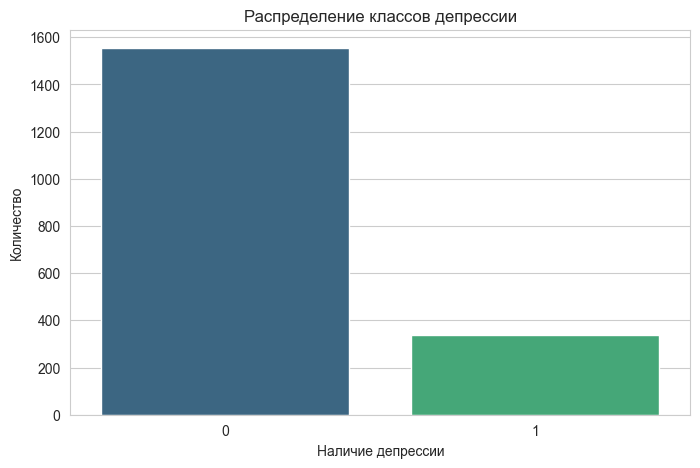

In [5]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x=y, palette='viridis')
plt.title('Распределение классов депрессии')
plt.xlabel('Наличие депрессии')
plt.ylabel('Количество')
plt.show()

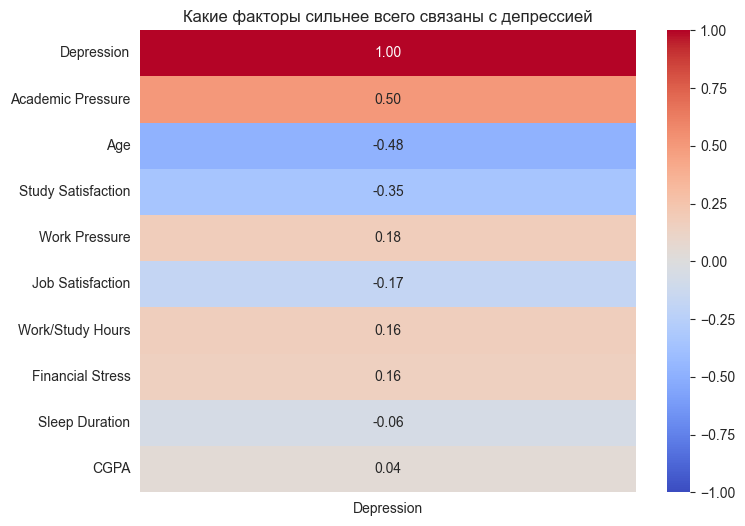

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузка данных
train_df = pd.read_csv("train.csv")

# Обработка данных (как в вашем коде)
train_df = process_time_intervals(train_df)

# 1. Выбираем только числовые признаки
numeric_cols = ['Age', 'CGPA', 'Sleep Duration', 'Work/Study Hours',
               'Academic Pressure', 'Work Pressure', 'Financial Stress',
               'Study Satisfaction', 'Job Satisfaction', 'Depression']

# 2. Считаем корреляцию с Depression
corr_with_depression = train_df[numeric_cols].corr()[['Depression']]

# 3. Сортируем по силе связи (по модулю)
corr_sorted = corr_with_depression.iloc[(-corr_with_depression['Depression'].abs()).argsort()]

# 4. Красиво отображаем
plt.figure(figsize=(8, 6))
sns.heatmap(corr_sorted, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Какие факторы сильнее всего связаны с депрессией')
plt.show()

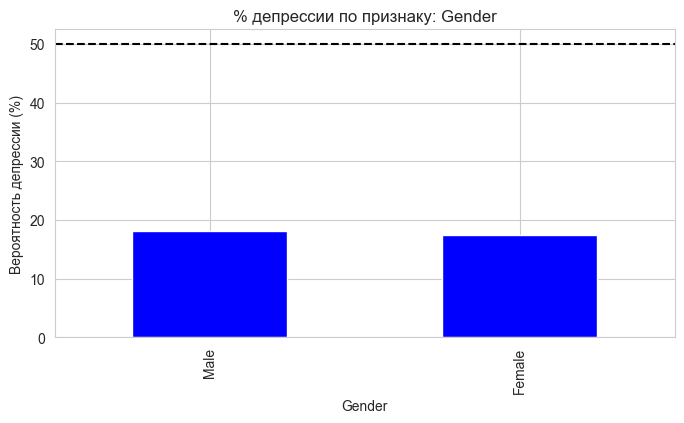

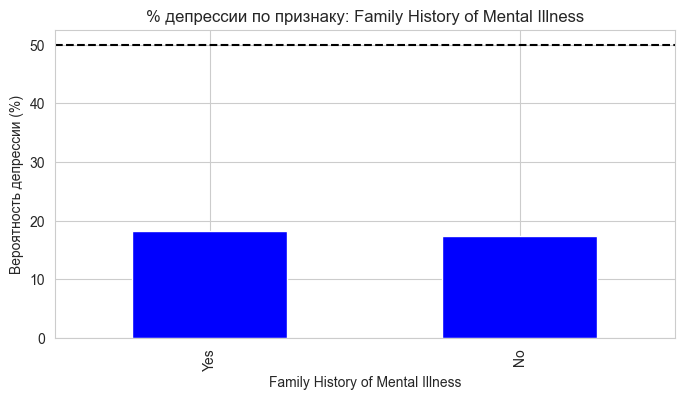

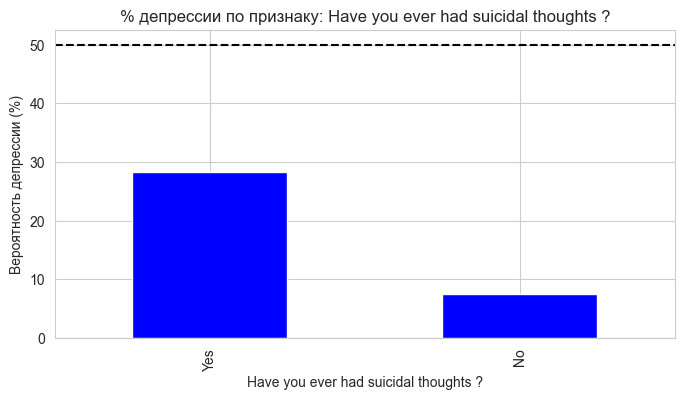

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Для каждого категориального признака
for col in ['Gender', 'Family History of Mental Illness', 'Have you ever had suicidal thoughts ?']:

    # Считаем процент депрессии в каждой группе
    dep_rate = train_df.groupby(col)['Depression'].mean() * 100

    # Сортируем по убыванию
    dep_rate = dep_rate.sort_values(ascending=False)

    # Рисуем график
    plt.figure(figsize=(8, 4))
    dep_rate.plot(kind='bar', color=['red' if x > 50 else 'blue' for x in dep_rate])
    plt.title(f'% депрессии по признаку: {col}')
    plt.ylabel('Вероятность депрессии (%)')
    plt.axhline(50, color='black', linestyle='--')  # Линия 50%
    plt.show()

C:\Users\кошька\AppData\Local\Temp\ipykernel_3504\58248035.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y='Sleep Duration', data=X, palette='pastel')


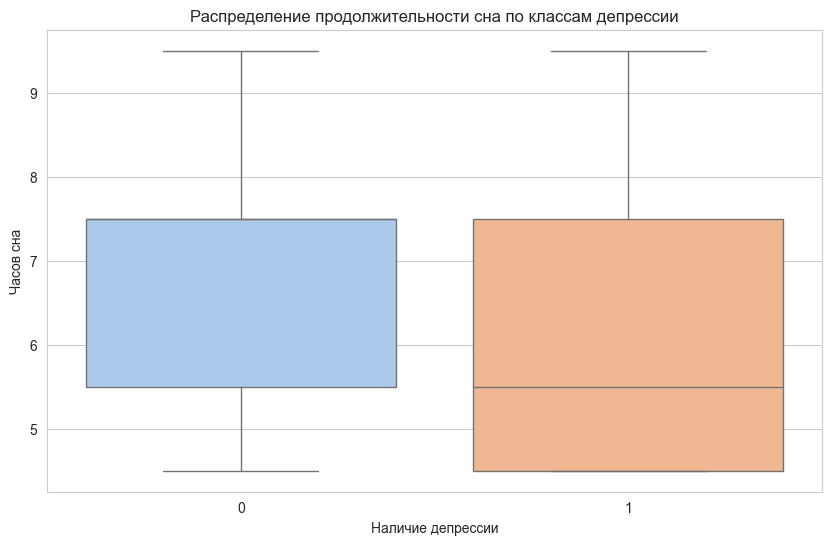

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(x=y, y='Sleep Duration', data=X, palette='pastel')
plt.title('Распределение продолжительности сна по классам депрессии')
plt.xlabel('Наличие депрессии')
plt.ylabel('Часов сна')
plt.show()

In [8]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42))
])

In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_val)

print("F1-score на валидации:", f1_score(y_val, y_pred))


model.fit(X, y)
test_pred = model.predict(X_test)

submission = pd.DataFrame({
    "id": test_df["id"],
    "Depression": test_pred
})
submission.to_csv("submission.csv", index=False)


F1-score на валидации: 0.9379310344827586
